In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

## Dataset read-in and details

In [2]:
df = pd.read_csv('./data/telco_customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Feature Relationships

### What percentage of customers churned?

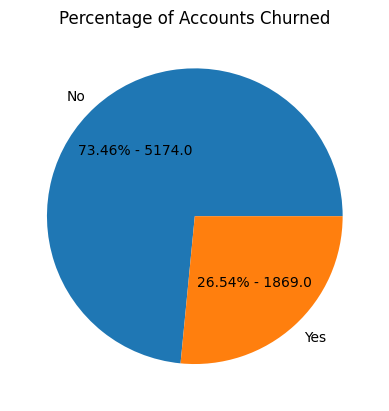

In [8]:
churned_values = df["Churn"].value_counts()
labels = df["Churn"].unique()
total = len(df["Churn"])

def get_autopct(values):
    def make_autopct(val):
        a =  np.round(val*total/100, 0)
        return "{:.2f}% - {}".format(val, a)
    return make_autopct
        

plt.pie(data=df, x=churned_values, labels=labels, autopct=get_autopct(churned_values))
plt.title("Percentage of Accounts Churned")
plt.show()

### Which features are most predictive of whether a customer churns?

In [9]:
# Need binary churned values
df_copy = df.copy()
binary_mappings = {
    "gender":{"Male":0, "Female":1},
    "Partner":{"No":0, "Yes":1},
    "Dependents":{"No":0, "Yes":1},
    "PhoneService":{"No":0, "Yes":1},
    "PaperlessBilling":{"No":0, "Yes":1},
    "Churn":{"No":0, "Yes":1},
}
for feature, val in binary_mappings.items():
    df_copy[feature] = df_copy[feature].map(val)

df_copy.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,0,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,0,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,0,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,1,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [10]:
df_copy[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']].corr()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Churn
gender,1.000000,0.001874,0.001808,-0.010517,0.006488,0.011754,0.008612
SeniorCitizen,0.001874,1.000000,0.016479,-0.211185,0.008576,0.156530,0.150889
Partner,0.001808,0.016479,1.000000,0.452676,0.017706,-0.014877,-0.150448
Dependents,-0.010517,-0.211185,0.452676,1.000000,-0.001762,-0.111377,-0.164221
PhoneService,0.006488,0.008576,0.017706,-0.001762,1.000000,0.016505,0.011942
PaperlessBilling,0.011754,0.156530,-0.014877,-0.111377,0.016505,1.000000,0.191825
Churn,0.008612,0.150889,-0.150448,-0.164221,0.011942,0.191825,1.000000


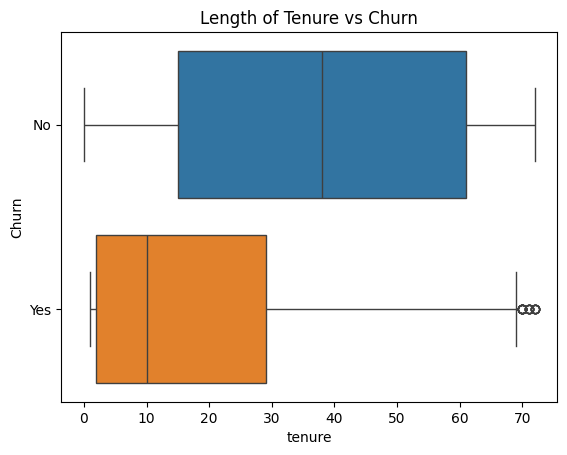

In [11]:
sns.boxplot(data=df, x='tenure', y = 'Churn', hue='Churn')
plt.title("Length of Tenure vs Churn")
plt.show()

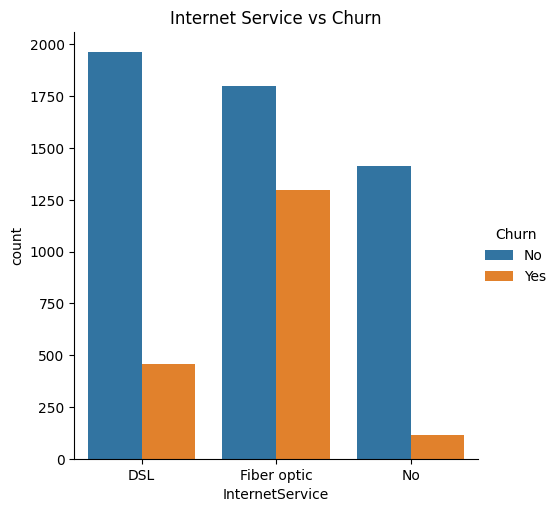

In [12]:
sns.catplot(kind='count', data=df,  x='InternetService', hue='Churn')
plt.title("Internet Service vs Churn")
plt.show()

Text(0.5, 1.0, 'Gender vs Churn')

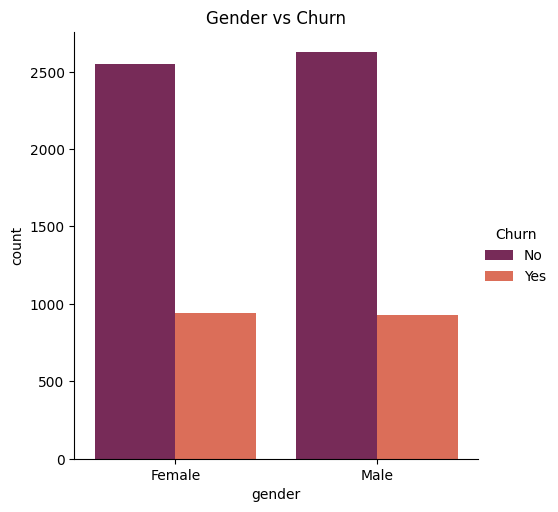

In [13]:
sns.catplot(kind='count', data=df, x='gender', hue='Churn', palette='rocket')
plt.title('Gender vs Churn')

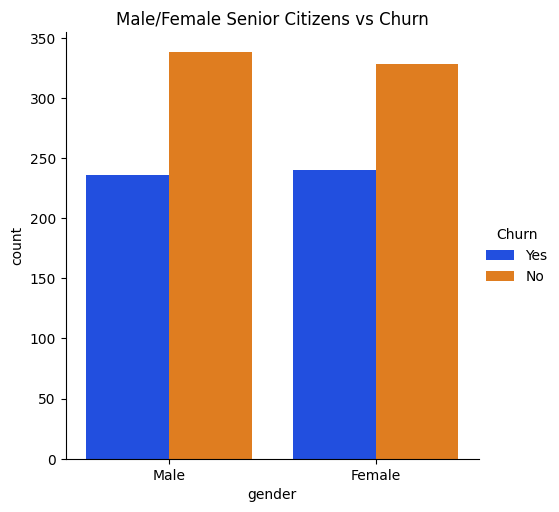

In [14]:
is_senior = df[df['SeniorCitizen'] == 1]
sns.catplot(kind='count', data=is_senior, x='gender', hue='Churn', palette='bright')
plt.title('Male/Female Senior Citizens vs Churn')
plt.show()

## Monthly and Total Charges Affect Churn?

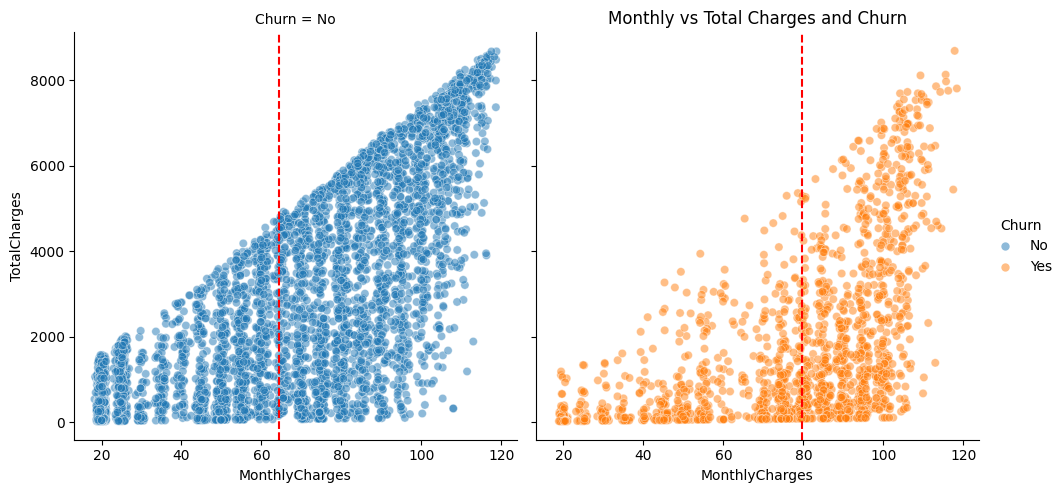

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
g = sns.relplot(kind='scatter', data=df, x='MonthlyCharges', y='TotalCharges', col='Churn', hue='Churn', alpha=0.5)
medians = df.groupby('Churn')['MonthlyCharges'].median()
for ax, churn_value in zip(g.axes.flatten(), medians.index):
    ax.axvline(x=medians[churn_value], color='red', linestyle='--')
plt.title('Monthly vs Total Charges and Churn')
plt.show()

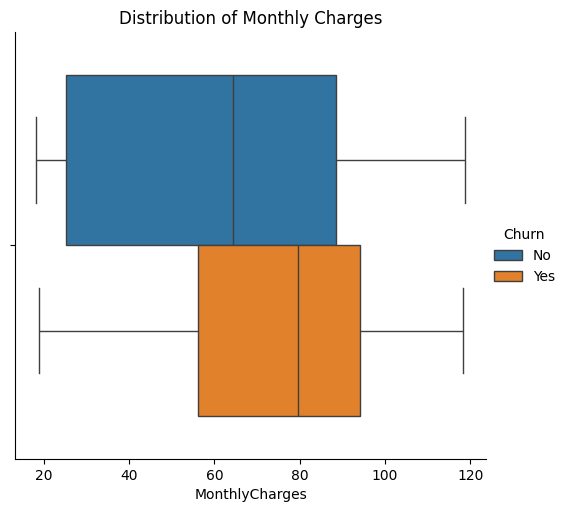

In [16]:
sns.catplot(kind='box', data=df, x='MonthlyCharges', hue='Churn')
plt.title('Distribution of Monthly Charges')
plt.show()

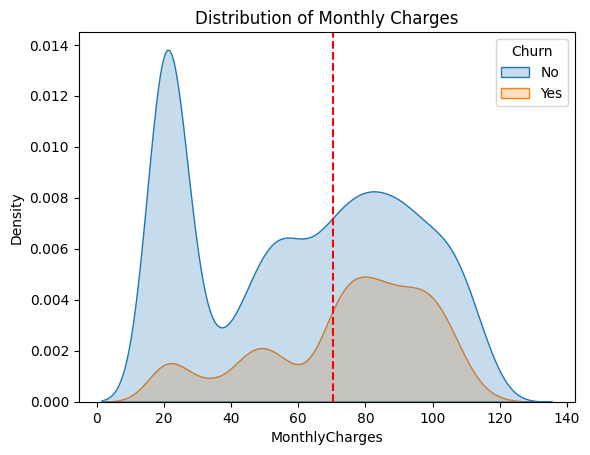

In [26]:
ax = sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
ax.axvline(x=df['MonthlyCharges'].median(), color='red', linestyle='--')
plt.title("Distribution of Monthly Charges")
plt.show()

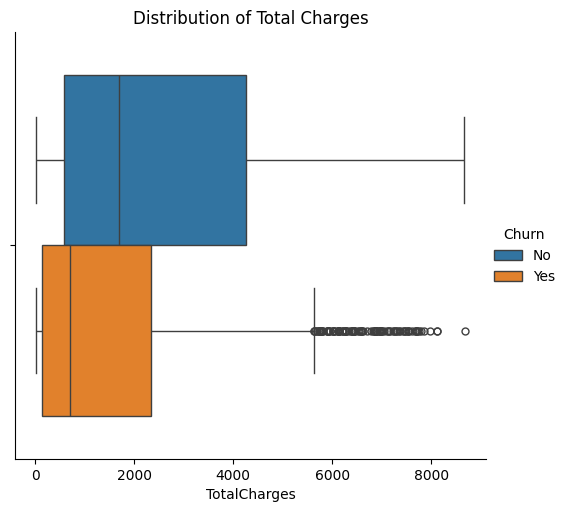

In [17]:
sns.catplot(kind='box', data=df, x='TotalCharges', hue='Churn')
plt.title('Distribution of Total Charges')
plt.show()

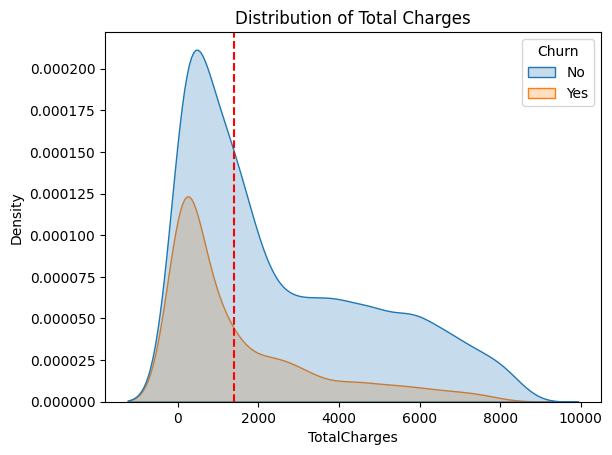

In [18]:
ax = sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True)
ax.axvline(x=df['TotalCharges'].median(), color='red', linestyle='--')
plt.title("Distribution of Total Charges")
plt.show()

In [19]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [20]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

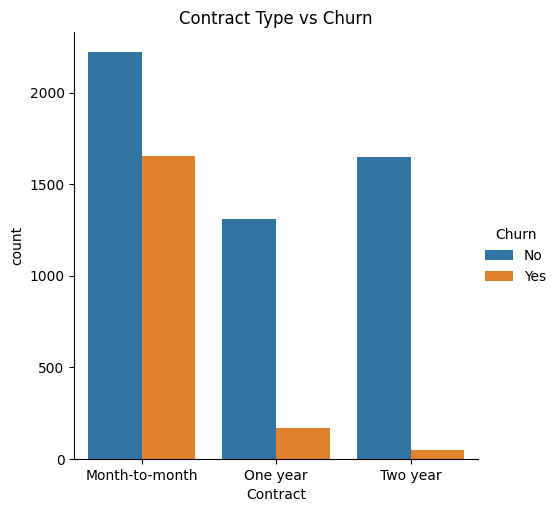

In [21]:
sns.catplot(kind='count', data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.show()

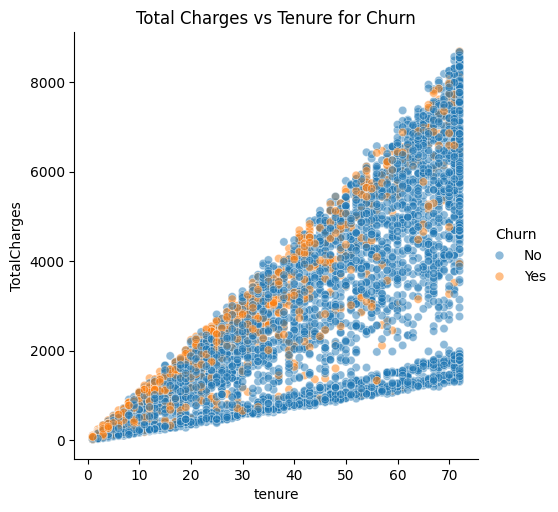

In [22]:
sns.relplot(kind='scatter', data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.5)
plt.title('Total Charges vs Tenure for Churn')
plt.show()

In [23]:
df_copy['tenure_bin'] = pd.cut(df_copy['tenure'], bins=10)
df_copy.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bin
0,7590-VHVEG,1,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,"(-0.072, 7.2]"
1,5575-GNVDE,0,0,0,0,34,1,No,DSL,Yes,...,No,No,No,One year,0,Mailed check,56.95,1889.5,0,"(28.8, 36.0]"
2,3668-QPYBK,0,0,0,0,2,1,No,DSL,Yes,...,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,"(-0.072, 7.2]"
3,7795-CFOCW,0,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,"(43.2, 50.4]"
4,9237-HQITU,1,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,"(-0.072, 7.2]"


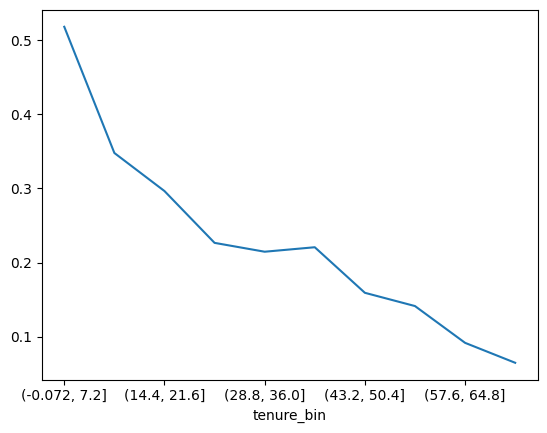

In [24]:
df_copy.groupby('tenure_bin', observed=True)['Churn'].mean().plot()
plt.show()

### Train/Test

#### Need one-hot encoding for categorical values: Contract and Internet Service

In [60]:
df_copy = pd.get_dummies(
    df_copy,
    prefix=['contract', 'internet_service'],
    columns=['Contract', 'InternetService'],
    dtype=int
)

In [64]:
features = df_copy[['contract_Month-to-month','contract_One year', 'contract_Two year', 'tenure', 'internet_service_DSL', 'internet_service_Fiber optic', 'internet_service_No', 'MonthlyCharges', 'TotalCharges']].values
target = df_copy['Churn'].values

X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size=0.4, random_state=42)

### Model Fit

In [67]:
X_train

array([[1, 0, 0, ..., 0, 70.3, '132.4'],
       [1, 0, 0, ..., 0, 44.0, '44'],
       [1, 0, 0, ..., 0, 64.4, '1802.15'],
       ...,
       [1, 0, 0, ..., 1, 21.15, '306.05'],
       [1, 0, 0, ..., 0, 99.45, '1200.15'],
       [0, 1, 0, ..., 1, 19.8, '457.3']], shape=(4225, 9), dtype=object)

In [68]:
Y_train

array([0, 0, 0, ..., 0, 1, 0], shape=(4225,))

### Model Testing & Evaluation